In [1]:
import numpy as np  
import matplotlib.pyplot as plt

In [2]:
import h5py
f = h5py.File('sample_2e7_design_precessing_higherordermodes_3detectors.h5', 'r')

In [3]:
f.keys()

<KeysViewHDF5 ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'det', 'iota', 'mtot', 'psi', 'q', 'ra', 'snr', 'z']>

The file is very big. Let's downsampling the set for an initial investigation

In [4]:
howmany=int(1e4)

We don't include snr (it is the answer)

In [5]:
X=[]
for l in ['chi1x', 'chi1y', 'chi1z', 'chi2x', 'chi2y', 'chi2z', 'dec', 'iota', 'mtot', 'psi', 'q', 'ra','z']:
    X.append(f[l][:howmany])

X = np.array(X).T
y = np.array(f['det'][:howmany])                        #labels (detected or not)

Maybe not all the features are informative or a combination of them is informative: let's try PCA

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Xscal = scaler.fit_transform(X)
n_components = 2
pca = PCA(n_components=2)
proj_features = pca.fit_transform(Xscal) 

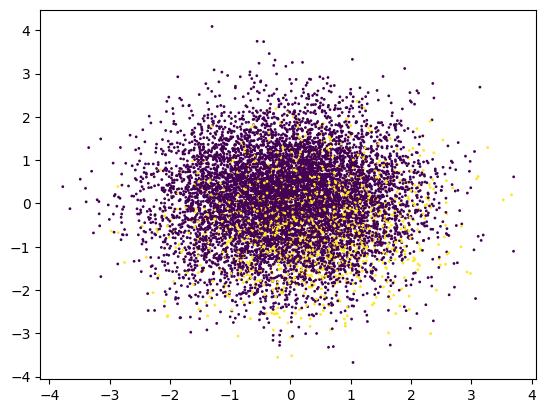

In [7]:
plt.scatter(proj_features[:, 0], proj_features[:, 1], c=y, cmap='viridis', s=1)

In [8]:
s = 0
for idx, r in enumerate(pca.explained_variance_ratio_):
    s += r #for the cumulative 
    print(f"Component {idx+1} explains {100*r:.1f}% of the variance (cumulative = {100*s:.1f})%")

Component 1 explains 8.1% of the variance (cumulative = 8.1)%
Component 2 explains 8.0% of the variance (cumulative = 16.1)%


In [9]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2,learning_rate=200, )
X_reduced = tsne.fit_transform(X)

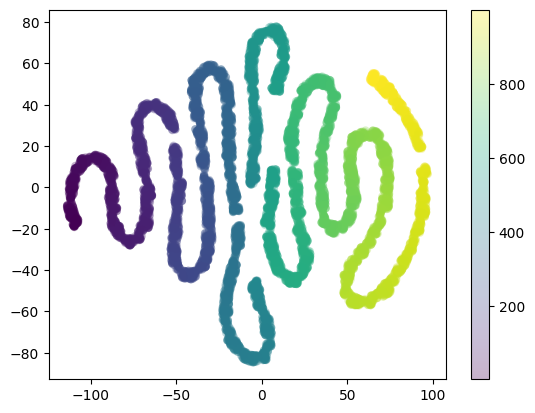

In [10]:
plt.scatter(X_reduced[:,0],X_reduced[:,1], c=X[:,8], alpha=0.3, edgecolor="None")
plt.colorbar()

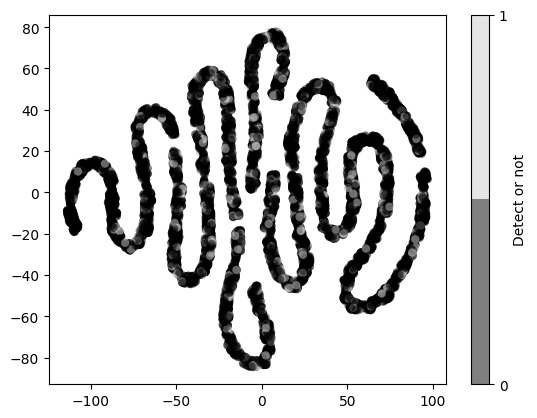

In [11]:
def discrete_cmap(N, base_cmap=None):
    base = plt.colormaps[base_cmap]
    color_list = base(np.linspace(0, 1, N))
    cmap_name = base.name + str(N)
    return base.from_list(cmap_name, color_list, N)
 
plt.scatter(X_reduced[:,0],X_reduced[:,1], c=y, edgecolor='none', alpha=0.5, cmap=discrete_cmap(2,'nipy_spectral'));

plt.colorbar(label='Detect or not', ticks=range(2))
plt.clim(0, 1)

In [31]:
from sklearn.manifold import Isomap
N=2 #number of dimensions 

X_scaled = StandardScaler().fit_transform(X)

iso = Isomap(n_components=N, n_neighbors=10) 
X_reduced_iso = iso.fit_transform(X_scaled)  


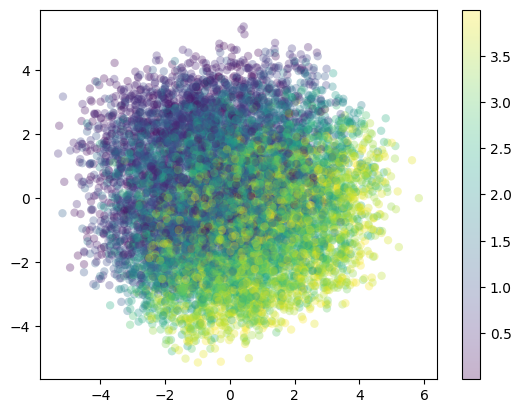

In [33]:
plt.scatter(X_reduced_iso[:,0],X_reduced_iso[:,1], c=X[:,12], alpha=0.3, edgecolor="None")
plt.colorbar()

In [12]:
import sklearn.model_selection
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.3, random_state=42)
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = sklearn.model_selection.train_test_split(X_reduced, y, test_size=0.3, random_state=42)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = sklearn.model_selection.train_test_split(proj_features, y, test_size=0.3, random_state=42)

In [13]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=0, max_depth=10,criterion='entropy')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

clf_tsne = DecisionTreeClassifier(random_state=0, max_depth=10,criterion='entropy')
clf_tsne.fit(X_train_tsne, y_train_tsne)
y_pred_tsne = clf_tsne.predict(X_test_tsne)

clf_pca = DecisionTreeClassifier(random_state=0, max_depth=10,criterion='entropy')
clf_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = clf_pca.predict(X_test_pca)

from sklearn.ensemble import BaggingClassifier
bag_clf = BaggingClassifier(DecisionTreeClassifier(random_state=42), n_estimators=500, max_samples=100, bootstrap=True, random_state=42, n_jobs=-1)
bag_clf.fit(X_train, y_train)
y_pred_bag = bag_clf.predict(X_test)

Efficency: number of thing classified corretly

In [14]:
C = sklearn.metrics.confusion_matrix(y_test, y_pred)
C2 = sklearn.metrics.confusion_matrix(y_test_tsne, y_pred_tsne)
C3 = sklearn.metrics.confusion_matrix(y_test_pca, y_pred_pca)
C4= sklearn.metrics.confusion_matrix(y_test, y_pred_bag)

print("Efficency:",np.sum(C.diagonal())/len(y_test))
print("Efficency:",np.sum(C2.diagonal())/len(y_test_tsne))
print("Efficency:",np.sum(C3.diagonal())/len(y_test_pca))
print("Efficency:",np.sum(C4.diagonal())/len(y_test))

Efficency: 0.949
Efficency: 0.8473333333333334
Efficency: 0.8296666666666667
Efficency: 0.9346666666666666


ROC curve plot

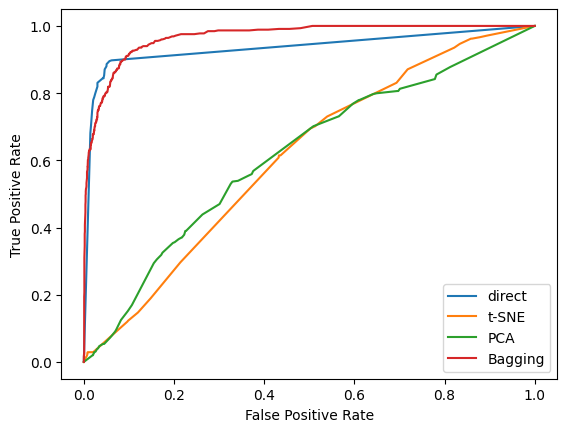

In [15]:

y_prob = clf.predict_proba(X_test)[:,1]
y_prob_tsne = clf_tsne.predict_proba(X_test_tsne)[:,1]
y_prob_pca = clf_pca.predict_proba(X_test_pca)[:,1]
y_prob_bag = bag_clf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, y_prob)
fpr_tsne, tpr_tsne, thresholds_tsne = sklearn.metrics.roc_curve(y_test_tsne, y_prob_tsne)
fpr_pca, tpr_pca, thresholds_pca = sklearn.metrics.roc_curve(y_test_pca, y_prob_pca)
fpr_bag, tpr_bag, thresholds_bag = sklearn.metrics.roc_curve(y_test, y_prob_bag)

plt.plot(fpr, tpr, label='direct');
plt.plot(fpr_tsne, tpr_tsne, label='t-SNE')
plt.plot(fpr_pca, tpr_pca, label='PCA')
plt.plot(fpr_bag, tpr_bag, label='Bagging')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()


In [16]:
importances = clf.feature_importances_
features_importance = np.argsort(importances)[::-1]     

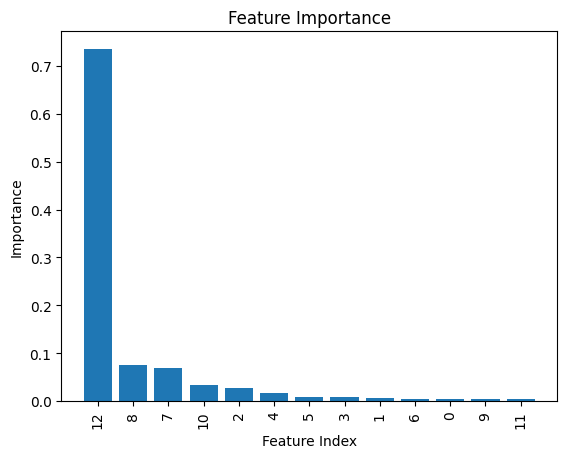

In [17]:
# Ordina le feature per importanza
features_importance = np.argsort(importances)[::-1]  # Rank importances (highest to lowest)

plt.bar(range(len(importances)), importances[features_importance], align='center')
plt.xticks(range(len(importances)), features_importance, rotation=90)  # Mostra gli indici delle feature
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Feature Importance')
plt.show()

The redshift seems to be far more informative then the other features
we can use onnly the first 3 features

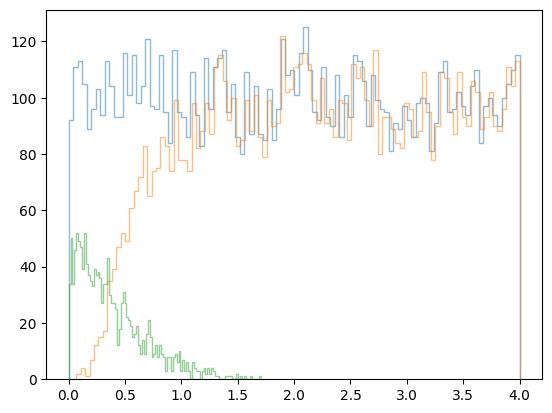

In [18]:
plt.hist(X[:,12], bins=100, alpha=0.5, label='z', histtype='step');
plt.hist(X[:,12][y==0], bins=100, alpha=0.5, label='z', histtype='step');
plt.hist(X[:,12][y==1], bins=100, alpha=0.5, label='z', histtype='step');

In [19]:
X_inf = X[:, features_importance[:3]]  #first 3 more informative features

Let's investigate the depth of the Tree (at some point there is OVERFITTING)

In [20]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.3, random_state=42)

completeness_test = []
contamination_test = []
completeness_train = []
contamination_train = []

md_vals = np.arange(1,20)
for md in md_vals:
    clf = DecisionTreeClassifier(random_state=42, max_depth=md,criterion='gini')
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    C = sklearn.metrics.confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = C.ravel()
    completeness_test.append(tp/(tp+fn))
    contamination_test.append(fp/(tp+fp))

    y_pred = clf.predict(X_train)
    C = sklearn.metrics.confusion_matrix(y_train, y_pred)
    tn, fp, fn, tp = C.ravel()
    completeness_train.append(tp/(tp+fn))
    contamination_train.append(fp/(tp+fp))
    

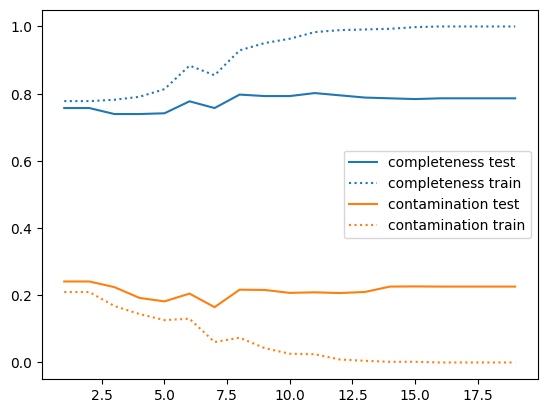

In [21]:
plt.plot(md_vals,completeness_test,label='completeness test',c='C0')
plt.plot(md_vals,completeness_train,label='completeness train',c='C0',ls='dotted')

plt.plot(md_vals,contamination_test,label='contamination test',c='C1')
plt.plot(md_vals,contamination_train,label='contamination train',c='C1',ls='dotted')
plt.legend();

In [22]:
print("completeness test", np.array(completeness_test)[md_vals==7])
print("contamination test", np.array(contamination_test)[md_vals==7])
print("completeness train", np.array(completeness_train)[md_vals==7])
print("contamination train", np.array(contamination_train)[md_vals==7])

completeness test [0.75723831]
contamination test [0.16461916]
completeness train [0.85488648]
contamination train [0.06073753]
